# Optimization Endterm


## Dataset 


Link to the dataset that we will use for this project:
[Traffic Sign Recogntion Database](https://nlpr.ia.ac.cn/pal/trafficdata/recognition.html)

### About the dataset

The TSRD includes 6164 traffic sign images containing 58 sign categories. The images are devided into two sub-database as training database and testing database. The training database includes 4170 images while the testing one contains 1994 images. All images are annotated the four corrdinates of the sign and the category.

**Our dataset consists of:**
- TSRD-Train (4170 images)
- TSRD-Train Annotation
- TSRD-Test (1994 images)
- TSRD-Test Annotation

**Annotation files looks like this:**

000_0001.png;134;128;19;7;120;117;0;

<filename>; x1; y1; x2; y2; x3; y3; classID;



In [2]:
import os, warnings
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from PIL import Image

from pathlib import Path
warnings.filterwarnings("ignore")   

## Dataset Preparation

We will create 'train/' and 'test/' with separate folders from 1-58 categories

In [33]:
OUTPUT_DATASET_DIR = r"C:\Outlook-alua\OneDrive\Рабочий стол\uni-itm\2nd semester\Optimization_Modelling\Endterm\dataset_full"
os.makedirs(os.path.join(OUTPUT_DATASET_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DATASET_DIR, 'test'), exist_ok=True)

def organize_images(ann_file, img_dir, out_subdir):
     """
     ann_file: path to the annotation file
     img_dir: directory with images
     out_subdir: 'train' or 'test'
     """
        
        with open(ann_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
             # Each line might look like:
             # 000_0001.png;134;128;19;7;120;117;0;
             # We only need the filename and classID
             parts = line.split(';')
             # Remove empty trailing part if the line ends with a semicolon
             if parts[-1] == '':
                parts = parts[:-1]
            
                filename = parts[0]
                class_id = parts[-1]  # last is the class, e.g. '0'

             # Build source path
             src_path = os.path.join(img_dir, filename)
                if not os.path.exists(src_path):
                    print(f"[Warning] Missing image: {src_path}")
                    continue
            
             # Create the class subfolder if needed
                class_dir = os.path.join(OUTPUT_DATASET_DIR, out_subdir, class_id)
                os.makedirs(class_dir, exist_ok=True)
            
             # Copy the image
                dst_path = os.path.join(class_dir, filename)
                shutil.copy(src_path, dst_path)

 # Organize train images
organize_images(TRAIN_ANN_PATH, TRAIN_IMG_DIR, 'train')

 # Organize test images
organize_images(TEST_ANN_PATH, TEST_IMG_DIR, 'test')

print("Done organizing images.")

Done organizing images.


- **train_transform** includes resizing, flipping, and rotation (for augmentation)

- **test_transform** includes just resizing and normalization

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 64
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR  = Path(r"C:\Outlook-alua\OneDrive\Рабочий стол\uni-itm\2nd semester\Optimization_Modelling\Endterm\dataset_full")     # <‑‑ change only here
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR  / "test"


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# data loading
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

### Helper functions

🔷 **plot_confusion()**

Draws a heatmap of predicted vs actual classes.

🔷 **plot_roc_auc()**

Calculates and plots ROC-AUC for each class.

🔷 **evaluate_metrics()**

Returns accuracy, precision, recall, and F1-score (macro average).

In [4]:
def plot_confusion(true, pred, title="Confusion Matrix"):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def plot_roc_auc(y_true, y_prob, n_classes, title="ROC-AUC"):
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    plt.figure(figsize=(10, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1


## CNN Model

In the very first running of this model, we faced an error with an accuracy, because it wass 81% for training, while it was very low (18%) in test.

So the problem  is **label mapping mismatch**. Because classes that were presented in train datas, weren't in test dataset. As a solution, it was resolved by ensuring identical folder sets. So we deleted 4 classes in train data.

### Architecture:
- 3 convolutional layer + dropout + 2FC layers
- trained on 10 epochs, and 64x64 resized images

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [6]:
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for epoch in range(EPOCHS):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss/total:.4f}, Acc: {correct/total:.4f}")

def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

results = {}

Epoch 1/10, Loss: 3.2820, Acc: 0.1830
Epoch 2/10, Loss: 2.2579, Acc: 0.3610
Epoch 3/10, Loss: 1.7619, Acc: 0.4699
Epoch 4/10, Loss: 1.4141, Acc: 0.5501
Epoch 5/10, Loss: 1.1872, Acc: 0.6185
Epoch 6/10, Loss: 1.0559, Acc: 0.6621
Epoch 7/10, Loss: 0.9423, Acc: 0.6833
Epoch 8/10, Loss: 0.8642, Acc: 0.7129
Epoch 9/10, Loss: 0.7804, Acc: 0.7305
Epoch 10/10, Loss: 0.7054, Acc: 0.7601


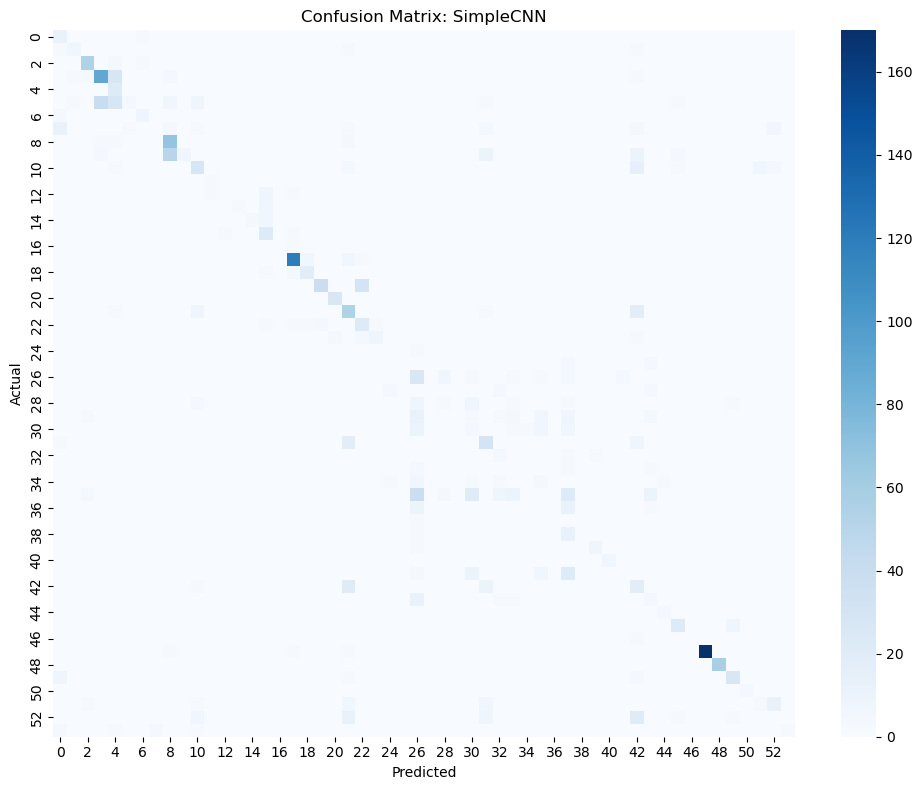

In [7]:
model_cnn = SimpleCNN(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)
train_model(model_cnn, train_loader, criterion, optimizer)
y_true_cnn, y_pred_cnn, y_prob_cnn = test_model(model_cnn, test_loader)
acc, prec, rec, f1 = evaluate_metrics(y_true_cnn, y_pred_cnn)
results['SimpleCNN'] = (acc, prec, rec, f1)
plot_confusion(y_true_cnn, y_pred_cnn, "Confusion Matrix: SimpleCNN")

## HOG + SVM Model

Images loaded and resized with PIL.

**HOG (Histogram of Oriented Gradients)** used for feature extraction.

SVC classifier (linear kernel, probability enabled)

In [17]:
from PIL import Image

def load_images_and_labels(folder):
    X, y = [], []
    for label_name in sorted(os.listdir(folder)):
        class_folder = os.path.join(folder, label_name)
        if not os.path.isdir(class_folder):
            continue
        label = int(label_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            try:
                img = Image.open(img_path).convert('L')  # Grayscale
                img = img.resize((64, 64))
                X.append(np.array(img))
                y.append(label)
            except Exception as e:
                print(f"Warning: failed to load {img_path}: {e}")
                continue
    print(f"Loaded {len(X)} images from {folder}")
    return np.array(X), np.array(y)


Loaded 4152 images from C:\Outlook-alua\OneDrive\Рабочий стол\uni-itm\2nd semester\Optimization_Modelling\Endterm\dataset_full\train
Loaded 1994 images from C:\Outlook-alua\OneDrive\Рабочий стол\uni-itm\2nd semester\Optimization_Modelling\Endterm\dataset_full\test


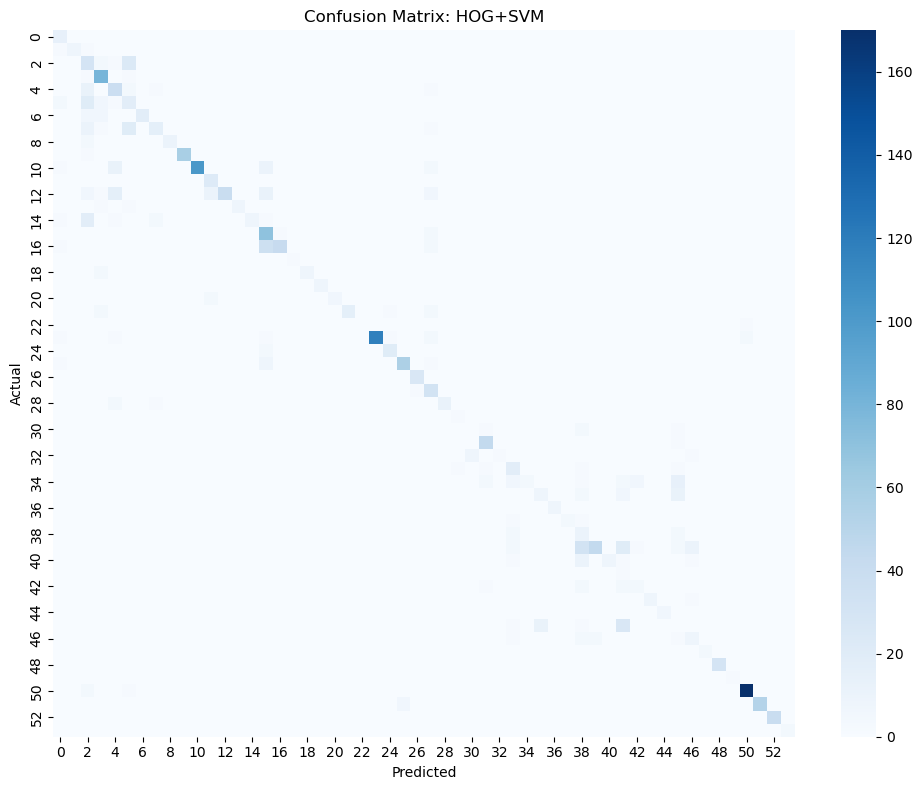

In [18]:
X_train_imgs, y_train = load_images_and_labels(TRAIN_DIR)
X_test_imgs, y_test = load_images_and_labels(TEST_DIR)
X_train_hog = extract_hog_features(X_train_imgs)
X_test_hog = extract_hog_features(X_test_imgs)

hog_svm = SVC(kernel='linear', probability=True)
hog_svm.fit(X_train_hog, y_train)
y_pred_hog = hog_svm.predict(X_test_hog)
y_prob_hog = hog_svm.predict_proba(X_test_hog)
acc, prec, rec, f1 = evaluate_metrics(y_test, y_pred_hog)
results['HOG+SVM'] = (acc, prec, rec, f1)
plot_confusion(y_test, y_pred_hog, "Confusion Matrix: HOG+SVM")

## ResNet18 Embeddings + SVM

- Pretrained ResNet18 used as a feature extractor

   - Final FC layer removed (fc = Identity())

- Embeddings extracted and passed to SVM

In [19]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet.eval().to(device)

resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



In [20]:
def extract_resnet_features(folder):
    features, labels = [], []
    for class_name in sorted(os.listdir(folder)):
        class_folder = os.path.join(folder, class_name)
        label = int(class_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            img = Image.open(img_path).convert('RGB')
            img_t = resnet_preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = resnet(img_t).cpu().numpy().flatten()
            features.append(feat)
            labels.append(label)
    return np.array(features), np.array(labels)



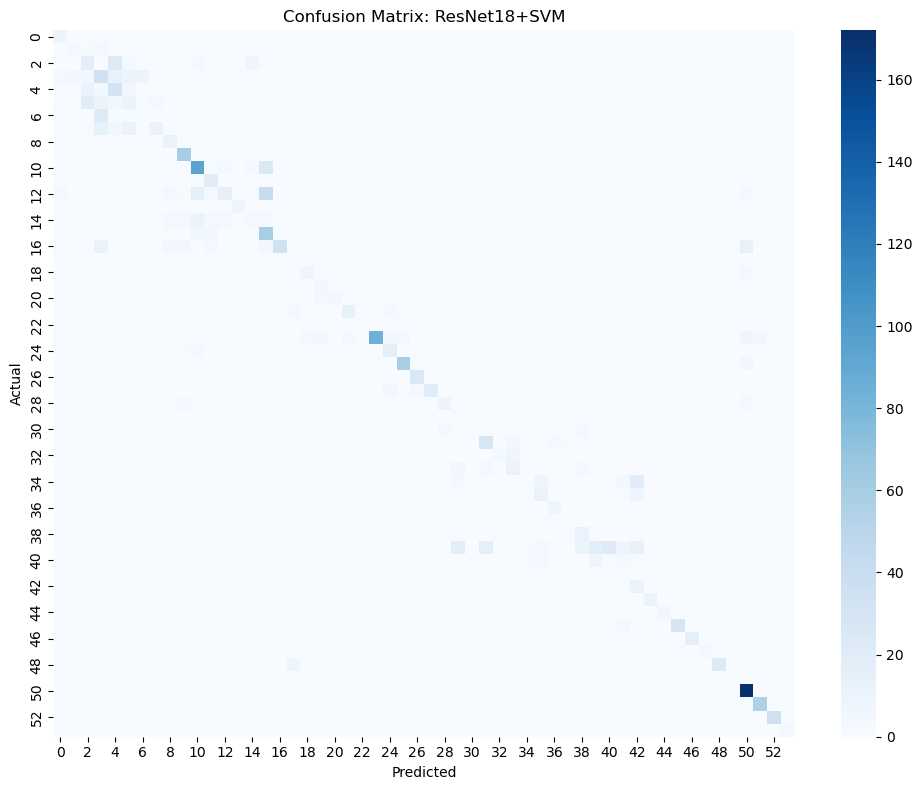

In [21]:
X_train_resnet, y_train_resnet = extract_resnet_features(TRAIN_DIR)
X_test_resnet, y_test_resnet = extract_resnet_features(TEST_DIR)
resnet_svm = SVC(kernel='linear', probability=True)
resnet_svm.fit(X_train_resnet, y_train_resnet)
y_pred_resnet = resnet_svm.predict(X_test_resnet)
y_prob_resnet = resnet_svm.predict_proba(X_test_resnet)
acc, prec, rec, f1 = evaluate_metrics(y_test_resnet, y_pred_resnet)
results['ResNet18+SVM'] = (acc, prec, rec, f1)
plot_confusion(y_test_resnet, y_pred_resnet, "Confusion Matrix: ResNet18+SVM")

## Fine-tuned ResNet18

Pretrained ResNet18 loaded and final layer replaced with new classifier.

Entire model fine-tuned for 10 epochs.

Trained on 224×224 normalized images.

In [23]:
import time

fine_resnet = models.resnet18(pretrained=True)
fine_resnet.fc = nn.Linear(fine_resnet.fc.in_features, NUM_CLASSES)
fine_resnet = fine_resnet.to(device)

train_resnet = datasets.ImageFolder(TRAIN_DIR, transform=resnet_preprocess)
test_resnet = datasets.ImageFolder(TEST_DIR, transform=resnet_preprocess)

train_loader_resnet = DataLoader(train_resnet, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader_resnet = DataLoader(test_resnet, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fine_resnet.parameters(), lr=0.001)

print("\nStarting fine-tuning ResNet18...")
start_time = time.time()

for epoch in range(EPOCHS):
    fine_resnet.train()
    correct, total, epoch_loss = 0, 0, 0.0
    for images, labels in train_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = fine_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        epoch_loss += loss.item() * images.size(0)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/total:.4f}, Acc: {correct/total:.4f}")

print(f"Finished training in {(time.time() - start_time)/60:.2f} minutes")

# Evaluation
fine_resnet.eval()
y_true_fine, y_pred_fine, y_prob_fine = [], [], []

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images, labels = images.to(device), labels.to(device)
        outputs = fine_resnet(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, axis=1)

        y_true_fine.extend(labels.cpu().numpy())
        y_pred_fine.extend(preds.cpu().numpy())
        y_prob_fine.extend(probs.cpu().numpy())


Starting fine-tuning ResNet18...
Epoch 1, Loss: 0.4689, Acc: 0.8938
Epoch 2, Loss: 0.0543, Acc: 0.9870
Epoch 3, Loss: 0.0581, Acc: 0.9863
Epoch 4, Loss: 0.0267, Acc: 0.9937
Epoch 5, Loss: 0.0011, Acc: 1.0000
Epoch 6, Loss: 0.0003, Acc: 1.0000
Epoch 7, Loss: 0.0002, Acc: 1.0000
Epoch 8, Loss: 0.0002, Acc: 1.0000
Epoch 9, Loss: 0.0001, Acc: 1.0000
Epoch 10, Loss: 0.0001, Acc: 1.0000
Finished training in 58.20 minutes


KeyboardInterrupt: 


[Fine-tuned ResNet18 Metrics] Acc: 0.9805, Prec: 0.9515, Rec: 0.9800, F1: 0.9597


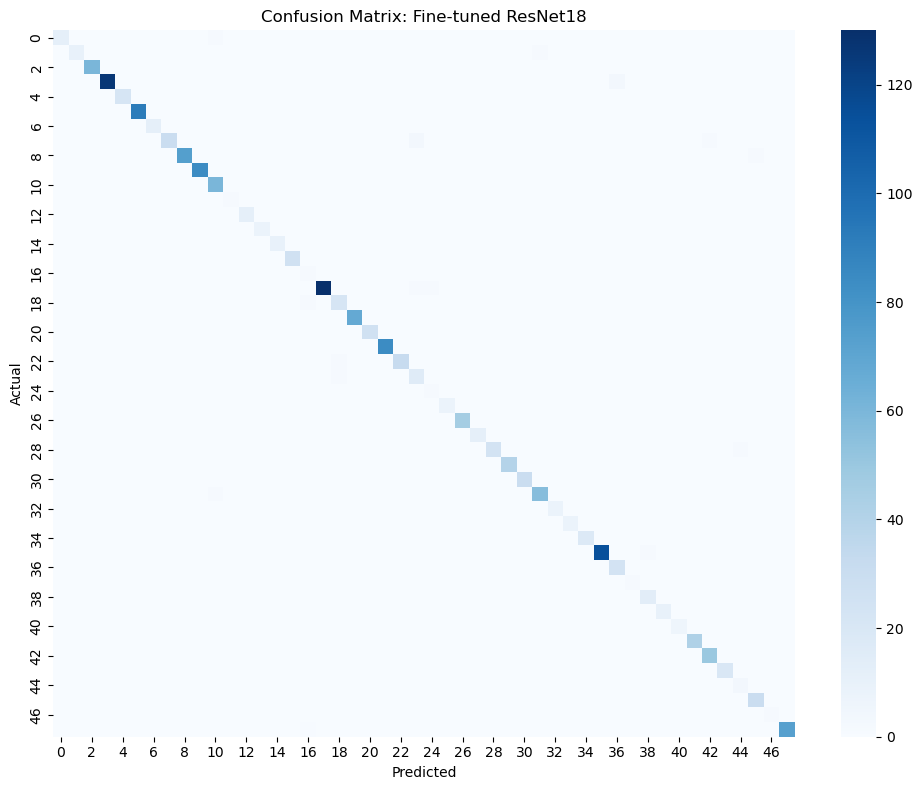

In [25]:
acc, prec, rec, f1 = evaluate_metrics(y_true_fine, y_pred_fine)
results['FineTunedResNet18'] = (acc, prec, rec, f1)
print(f"\n[Fine-tuned ResNet18 Metrics] Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
plot_confusion(y_true_fine, y_pred_fine, "Confusion Matrix: Fine-tuned ResNet18")

## Results Comparison

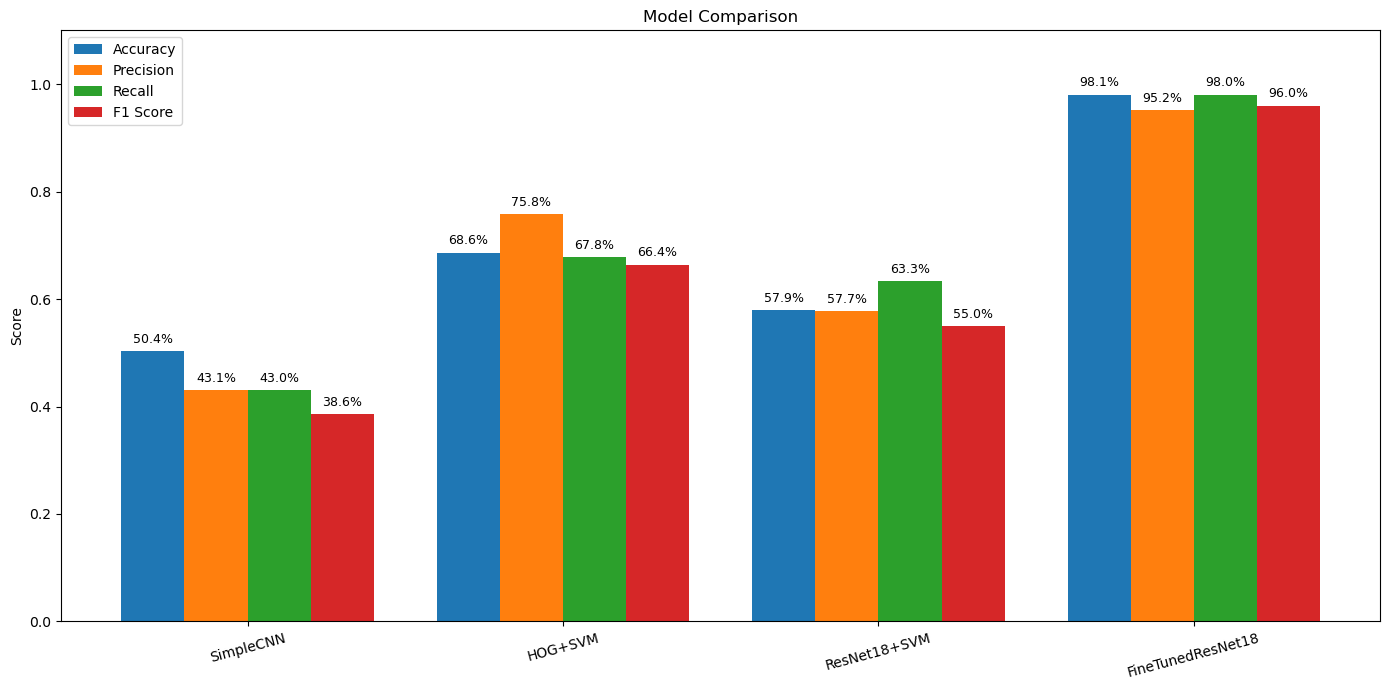

In [27]:
labels = list(results.keys())
accs = [v[0] for v in results.values()]
precs = [v[1] for v in results.values()]
recs = [v[2] for v in results.values()]
f1s = [v[3] for v in results.values()]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(14, 7))
bars1 = plt.bar(x - 1.5*width, accs, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precs, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recs, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1s, width, label='F1 Score')

plt.xticks(x, labels, rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.ylim(0, 1.1)

# Add percentage labels on top of bars
for bar_group in [bars1, bars2, bars3, bars4]:
    for bar in bar_group:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

As we can see from the bar plots above, **CNN** showed the lowest performance across all models. 

**HOG + SVM** suprisiongly has good precision, and since it is very lightweight and quick to run, can be considered as the best traditional model in this comparison.

**ResNet18 + SVM** performs worse than HOG + SVM. Probably because of overfitting and that SVM is not scaling well with hight dimensional features.

And top performer is **Fine-tuned ResNet18** model. But it has sligh overfitting, since in the training in last epochs it showed 100% accuracy. However, test results are solid.

## ROC-AUC curves

SimpleCNN macro ROC-AUC: 0.9544
HOG+SVM macro ROC-AUC: nan
ResNet18+SVM macro ROC-AUC: nan
FineTunedResNet18 macro ROC-AUC: nan


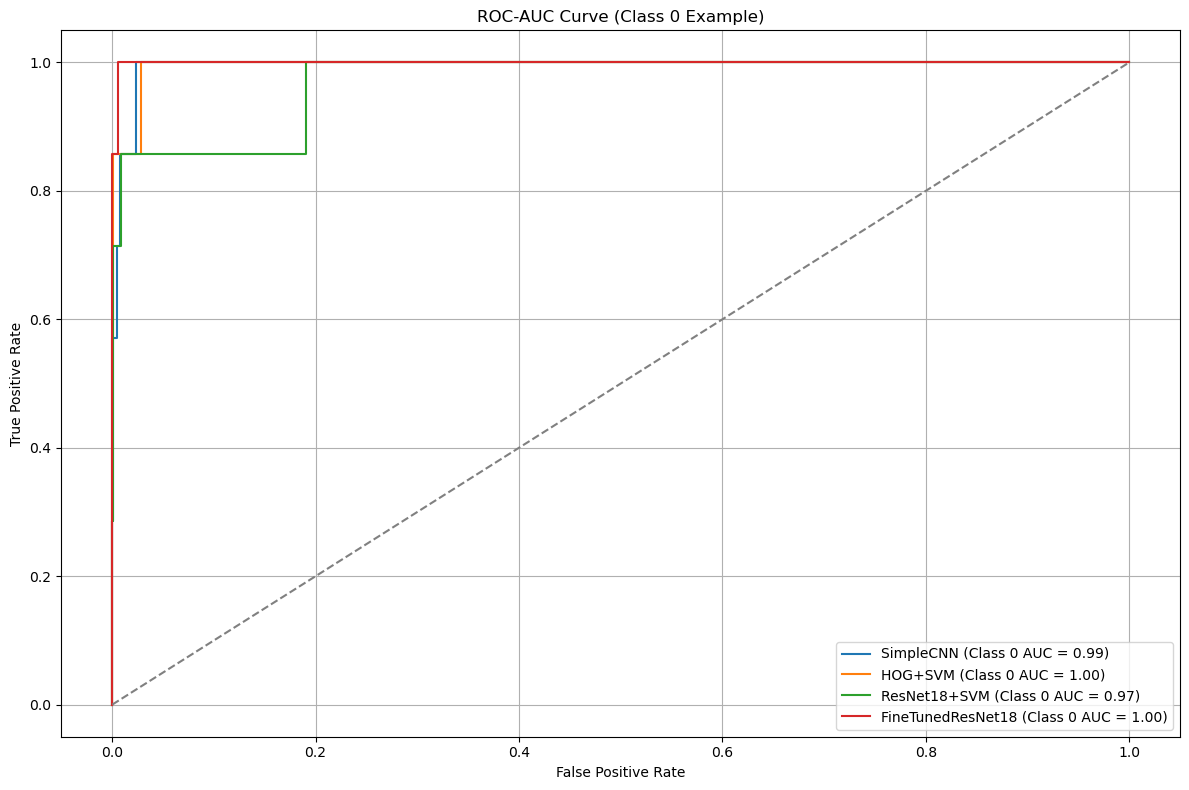

In [32]:
plt.figure(figsize=(12, 8))

model_probs = {
    "SimpleCNN": (y_true_cnn, y_prob_cnn),
    "HOG+SVM": (y_test, y_prob_hog),
    "ResNet18+SVM": (y_test_resnet, y_prob_resnet),
    "FineTunedResNet18": (y_true_fine, y_prob_fine)
}

for model_name, (y_true, y_prob) in model_probs.items():
    try:
        y_prob = np.array(y_prob) 
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        macro_auc = 0
        for i in range(NUM_CLASSES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            auc_score = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
            macro_auc += auc_score
            if i == 0:
                plt.plot(fpr, tpr, label=f"{model_name} (Class 0 AUC = {auc_score:.2f})")
        macro_auc /= NUM_CLASSES
        print(f"{model_name} macro ROC-AUC: {macro_auc:.4f}")
    except Exception as e:
        print(f"Could not compute ROC-AUC for {model_name}: {e}")


plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC-AUC Curve (Class 0 Example)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()